# Volatility Surface Calibration Engine 

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bs
import implied_vol as iv
import data
import svi
import arbitrage as arb
import ssvi
import surface
import global_essvi as ge

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)

## Step 1 — Data ingestion + smile extraction (`data.py`)

Pulls the live BTC option chain from Deribit's public API, filters illiquid quotes, and converts mids to implied vol.

In [2]:
CURRENCY = 'BTC'
raw = data.fetch_book_summary(CURRENCY)
chain = data.build_chain(raw)
print(f"{len(chain)} liquid quotes across {chain['expiry'].nunique()} expiries")
chain.head()

752 liquid quotes across 12 expiries


,strike,expiry,T,forward,mid_iv,weight,option_type,bid,ask,mid
0,74000.0,2026-09-02 08:00:00+00:00,0.001072,77093.18,0.598174,0.000027,C,3006.63402,3199.36697,3103.000495
1,77000.0,2026-09-02 08:00:00+00:00,0.001072,77093.18,0.331466,0.000673,P,269.82613,308.37272,289.099425
2,78500.0,2026-09-02 08:00:00+00:00,0.001072,77093.18,0.399212,0.000027,P,1349.13065,1541.86360,1445.497125
3,80500.0,2026-09-02 08:00:00+00:00,0.001072,77092.90,0.801162,0.000004,P,3199.35535,3700.45920,3449.907275
4,81000.0,2026-09-02 08:00:00+00:00,0.001072,77093.18,0.896883,0.000004,P,3700.47264,4201.57831,3951.025475


In [3]:
# acceptance criteria: no NaNs/negative vols after filtering
assert chain.isna().sum().sum() == 0
assert (chain['mid_iv'] > 0).all()

counts = chain.groupby('expiry').size().sort_values(ascending=False)
print(counts)

expiry
2026-12-25 08:00:00+00:00    98
2027-03-26 08:00:00+00:00    97
2027-06-25 08:00:00+00:00    96
2026-10-30 08:00:00+00:00    95
2026-09-25 08:00:00+00:00    87
2026-11-27 08:00:00+00:00    86
2026-09-04 08:00:00+00:00    39
2026-09-05 08:00:00+00:00    39
2026-09-18 08:00:00+00:00    39
2026-09-11 08:00:00+00:00    38
2026-09-03 08:00:00+00:00    26
2026-09-02 08:00:00+00:00    12
dtype: int64


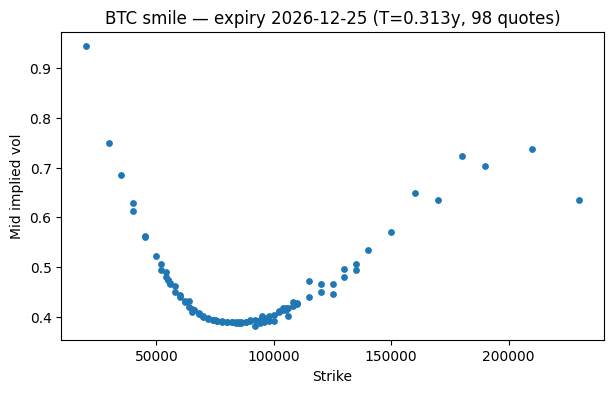

In [4]:
# smile for the most liquid expiry 
biggest_expiry = counts.idxmax()
slice_ = chain[chain['expiry'] == biggest_expiry].sort_values('strike')

plt.figure(figsize=(7,4))
plt.scatter(slice_['strike'], slice_['mid_iv'], s=15)
plt.xlabel('Strike'); plt.ylabel('Mid implied vol')
plt.title(f'{CURRENCY} smile — expiry {biggest_expiry.date()} (T={slice_["T"].iloc[0]:.3f}y, {len(slice_)} quotes)')
plt.show()

## Step 2 — SVI slice fit (`svi.py`)

Fit the raw SVI parameterization to the smile above, in total-variance space.

Fit first, check after. The SVI 5-parameter fit is not arbitrage-free constrained, so on live data it can land in an optimal curve that violates butterfly arbitrage 

SVIParams(a=np.float64(-0.09662852678823537), b=np.float64(0.22111723229327584), rho=np.float64(-0.27270757573247767), m=np.float64(-0.15240115430033477), sigma=np.float64(0.6730186833952715))
weighted RMSE (total variance): 0.001189845611570299
butterfly check: passed


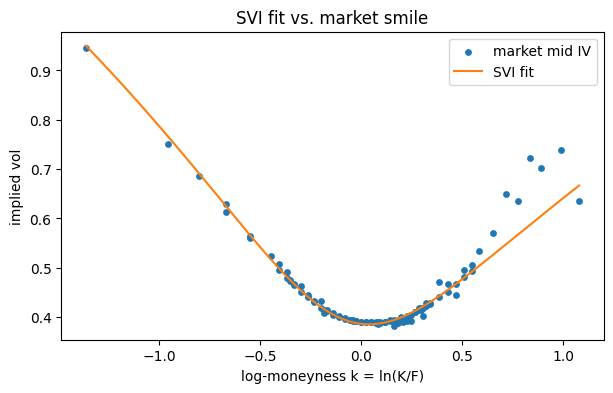

In [5]:
F = float(slice_['forward'].iloc[0])
T_slice = float(slice_['T'].iloc[0])
k = np.log(slice_['strike'].to_numpy() / F)

fit_result = svi.fit_svi_slice(k, slice_['mid_iv'].to_numpy(), slice_['weight'].to_numpy(), T_slice, validate=False)
print(fit_result.params)
print('weighted RMSE (total variance):', fit_result.weighted_rmse)
try:
    arb.check_butterfly(fit_result.params)
    print('butterfly check: passed')
except arb.ArbitrageError as exc:
    print('butterfly check: FAILED (unconstrained fit on today\'s smile) --', exc)

k_grid = np.linspace(k.min(), k.max(), 200)
fitted_iv = fit_result.params.implied_vol(k_grid, T_slice)

plt.figure(figsize=(7,4))
plt.scatter(k, slice_['mid_iv'], s=15, label='market mid IV')
plt.plot(k_grid, fitted_iv, color='C1', label='SVI fit')
plt.xlabel('log-moneyness k = ln(K/F)'); plt.ylabel('implied vol')
plt.legend(); plt.title('SVI fit vs. market smile')
plt.show()

## Step 3— No-arbitrage validation (`arbitrage.py`) on SVI slice above

### Butterfly check

A slice is free of butterfly arbitrage iff **both** (Gatheral & Jacquier, 2013, Lemma 2.2):

1. `g(k) >= 0` for all `k` — checked pointwise on a grid spanning realistic moneyness.
2. `lim_{k->+inf} d+(k) = -inf`, where `d+(k) = -k/sqrt(w(k)) + sqrt(w(k))/2` — an
   asymptotic (wing) condition the grid check cannot see, since no finite grid says
   anything about a limit.

`check_wing_condition` tests condition (ii) as the parameter bound `b*(1+rho) < 2` rather
than by evaluating the limit. **That is not an approximation of the limit — it is the limit,
in closed form.** Writing `c := b(1+rho)`, the tail expansion `w(k) ~ c*k + (a - c*m)` gives

```
d+(k) = [(c-2)k + (a-c*m)] / (2*sqrt(c*k + a-c*m))  ->  L*sqrt(k),   L := (c-2)/(2*sqrt(c))
```

so `d+` diverges at rate `sqrt(k)` with sign `L`, and `lim d+ = -inf` **iff** `L < 0` **iff**
`c < 2`. At `c = 2` exactly the `sqrt(k)` terms cancel and `d+ -> 0`, which is why the
inequality is strict.

Provenance: this bound is **not stated in the paper for raw SVI**. The paper gives Lemma
2.2's limit, and only puts a number on an asymptotic slope in Remark 4.3, for SSVI. The
step to raw SVI is ours.

The cell below tests condition (ii) **as an actual limit**, not as the parameter bound: it
measures `d+(k)/sqrt(k)` — the one quantity that converges — out to `k = 1e20`, checks it
against the closed-form `L`, confirms `c < 2` and `sign(L)` agree across 200,000 random
slices including ones sitting within `1e-9` of the boundary, and shows why sampling `d+`
itself is the unreliable route: it is a difference of two large near-equal terms, so near
`c = 2` it loses most of its significant digits to cancellation.

In [6]:
# --- condition (i): g(k) >= 0 on the grid ---
g_vals = arb.g_function(arb.DEFAULT_K_GRID, fit_result.params)
print('min g(k) over the check grid:', g_vals.min(),
      '-> condition (i) HOLDS' if g_vals.min() >= 0 else '-> VIOLATION')

min g(k) over the check grid: 0.10892940927074404 -> condition (i) HOLDS


In [7]:
# condition (ii): lim_{k->+inf} d+(k) = -inf, tested as an actual limit
p = fit_result.params
c_slope = p.b * (1 + p.rho)
L_closed = (c_slope - 2) / (2 * np.sqrt(c_slope))

k_probe = np.array([1e4, 1e8, 1e12, 1e16, 1e20])
ratio = arb.d_plus(k_probe, p) / np.sqrt(k_probe)

print(f'\nwing slope c = b(1+rho) = {c_slope:.6f}')
print('d+(k)/sqrt(k), which must converge to L = (c-2)/(2*sqrt(c)):')
for k_i, r_i in zip(k_probe, ratio):
    print(f'  k={k_i:.0e}:  {r_i:+.8e}')
print(f'  closed-form L = {L_closed:+.8e}   (measured matches to '
      f'{abs(ratio[-1] - L_closed):.1e})')
print(f'-> L {"<" if L_closed < 0 else ">="} 0, so lim d+(k) = '
      f'{"-inf: condition (ii) HOLDS" if L_closed < 0 else "+inf: VIOLATION"}')


wing slope c = b(1+rho) = 0.160817
d+(k)/sqrt(k), which must converge to L = (c-2)/(2*sqrt(c)):
  k=1e+04:  -2.29319290e+00
  k=1e+08:  -2.29313250e+00
  k=1e+12:  -2.29313249e+00
  k=1e+16:  -2.29313249e+00
  k=1e+20:  -2.29313249e+00
  closed-form L = -2.29313249e+00   (measured matches to 0.0e+00)
-> L < 0, so lim d+(k) = -inf: condition (ii) HOLDS


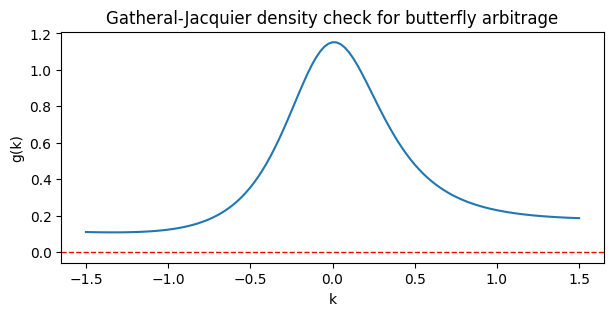

In [25]:
plt.figure(figsize=(7, 3))
plt.plot(arb.DEFAULT_K_GRID, g_vals)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('k'); plt.ylabel('g(k)')
plt.title('Gatheral-Jacquier density check for butterfly arbitrage')
plt.show()

### Calendar check (`check_calendar`) for two *most liquid* expiries

Total variance `w(k, T)` must be non-decreasing in `T` at fixed log-moneyness
`k`. `arbitrage.check_calendar`
takes a list of `(T, SVIParams)` pairs, sorts them by `T`, and checks every
**adjacent** pair on a shared `k` grid (each slice evaluated via its own
forward. It's run
once after every expiry has been fit -- unlike the
butterfly check, it needs neighboring slices, so it can't run per-slice.



T=0.3134 (98 quotes): SVIParams(a=np.float64(-0.09662852678823537), b=np.float64(0.22111723229327584), rho=np.float64(-0.27270757573247767), m=np.float64(-0.15240115430033477), sigma=np.float64(0.6730186833952715))
T=0.5627 (97 quotes): SVIParams(a=np.float64(-0.2666392432691792), b=np.float64(0.3216339105978228), rho=np.float64(-0.09850196214755724), m=np.float64(-0.039123242151394906), sigma=np.float64(1.1174091107160227))


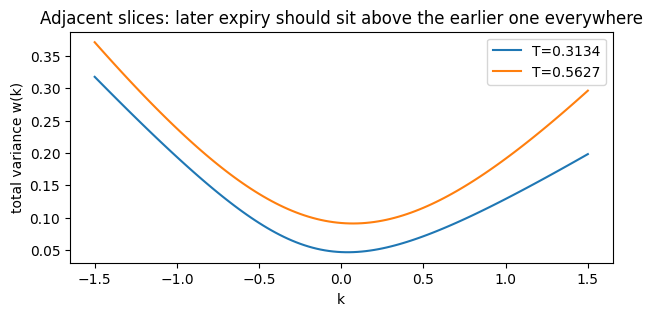

calendar check passed: total variance is non-decreasing across these expiries


In [11]:
# fit the two most liquid expiries and check the pair
most_liquid_expiries = counts.nlargest(2).index
two_T = sorted(chain[chain['expiry'].isin(most_liquid_expiries)]['T'].unique())

calendar_slices = []
for T_i in two_T:
    g_i = chain[chain['T'] == T_i]
    F_i = float(g_i['forward'].iloc[0])
    k_i = np.log(g_i['strike'].to_numpy() / F_i)
    res_i = svi.fit_svi_slice(k_i, g_i['mid_iv'].to_numpy(), g_i['weight'].to_numpy(), T_i, validate=False)
    calendar_slices.append((T_i, res_i.params))
    print(f"T={T_i:.4f} ({len(g_i)} quotes): {res_i.params}")

w_curves = [svi.raw_svi(arb.DEFAULT_K_GRID, *params.as_array()) for _, params in calendar_slices]
plt.figure(figsize=(7,3))
for (T_i, _), w_i in zip(calendar_slices, w_curves):
    plt.plot(arb.DEFAULT_K_GRID, w_i, label=f'T={T_i:.4f}')
plt.xlabel('k'); plt.ylabel('total variance w(k)'); plt.legend()
plt.title('Adjacent slices: later expiry should sit above the earlier one everywhere')
plt.show()

try:
    arb.check_calendar(calendar_slices)
    print('calendar check passed: total variance is non-decreasing across these expiries')
except arb.ArbitrageError as e:
    print('calendar arbitrage detected:', e)

### Exact calendar check (`check_calendar_exact`)

`check_calendar` above evaluates `w2 - w1` on `DEFAULT_K_GRID` -- fast, but
it steps across the `k` axis at fixed intervals, so a
violation narrower than that spacing can fall entirely between two grid
points and go undetected. 

`arbitrage.check_calendar_exact` instead finds
every *exact* intersection of two raw SVI slices via the closed-form
quartic from Gatheral & Jacquier (2013, Lemma 3.3) -- `find_slice_crossings`
solves `w(k;chi1) = w(k;chi2)` exactly (up to squaring-induced spurious
roots, filtered back out against the original equation).

First: run both checks on the live pair already fitted above (should
agree). Then: a constructed pair whose two crossings sit only ~0.0046
apart in `k` -- narrower than the grid spacing -- so `check_calendar`
misses the arbitrage entirely while `check_calendar_exact` catches it
exactly.

In [12]:
# run the exact check on the same live pair fitted above, and confirm it agrees
crossings_live = arb.find_slice_crossings(calendar_slices[0][1], calendar_slices[1][1])
print('exact crossings between the two live slices:', crossings_live)

try:
    arb.check_calendar_exact(calendar_slices)
    print('check_calendar_exact: passed (agrees with check_calendar above)')
except arb.ArbitrageError as e:
    print('check_calendar_exact: detected arbitrage ->', e)

exact crossings between the two live slices: []
check_calendar_exact: passed (agrees with check_calendar above)


exact crossings: [0.034474238507984124, 0.03911931052575252] (gap = 0.0046, grid spacing = 0.0250)


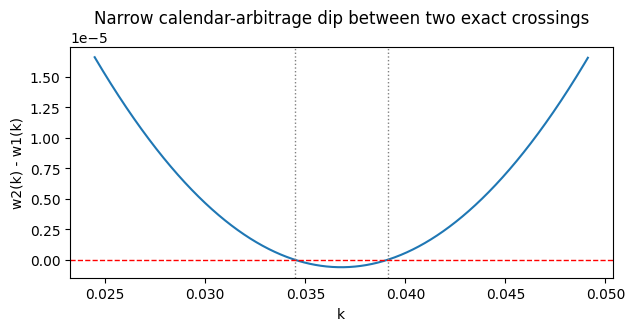

check_calendar (grid):        PASSED -- missed the arbitrage
check_calendar_exact (quartic): correctly caught it -> calendar arbitrage (exact) between T=0.1000 and T=0.5000: total variance ordering violated at k=0.0346 (drop 5.173e-08); slice crossings at k=[0.034474238507984124, 0.03911931052575252]


In [13]:
# A pair whose slices cross twice, ~0.0046 apart in k (found by random search) --
# narrow enough to slip between DEFAULT_K_GRID's ~0.025-wide steps entirely.
narrow_p1 = svi.SVIParams(a=0.02236232183296754, b=0.13667759465470686, rho=0.03925944666914394,
                           m=-0.012900631505364302, sigma=0.10832690341116893)
narrow_p2 = svi.SVIParams(a=0.02081207476543416, b=0.15249346064086547, rho=0.07957366224968813,
                           m=-0.0013092781972601879, sigma=0.10924503147696951)
narrow_pair = [(0.1, narrow_p1), (0.5, narrow_p2)]

crossings = arb.find_slice_crossings(narrow_p1, narrow_p2)
print('exact crossings:', crossings, f'(gap = {crossings[1]-crossings[0]:.4f}, grid spacing = {arb.DEFAULT_K_GRID[1]-arb.DEFAULT_K_GRID[0]:.4f})')

k_zoom = np.linspace(crossings[0] - 0.01, crossings[1] + 0.01, 2000)
w1_zoom = svi.raw_svi(k_zoom, *narrow_p1.as_array())
w2_zoom = svi.raw_svi(k_zoom, *narrow_p2.as_array())
plt.figure(figsize=(7, 3))
plt.plot(k_zoom, w2_zoom - w1_zoom)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
for k_star in crossings:
    plt.axvline(k_star, color='gray', linestyle=':', linewidth=1)
plt.xlabel('k'); plt.ylabel('w2(k) - w1(k)')
plt.title('Narrow calendar-arbitrage dip between two exact crossings')
plt.show()

try:
    arb.check_calendar(narrow_pair)
    print('check_calendar (grid):        PASSED -- missed the arbitrage')
except arb.ArbitrageError as e:
    print('check_calendar (grid):        caught it ->', e)

try:
    arb.check_calendar_exact(narrow_pair)
    print('check_calendar_exact (quartic): did not raise -- unexpected')
except arb.ArbitrageError as e:
    print('check_calendar_exact (quartic): correctly caught it ->', e)

## Step 4 — Full Implied Volatility surface (`surface.py`)

Runs the entire pipeline end-to-end with no manual intervention: ingest -> fit every slice -> validate -> interpolate -> plot.

### Three ways to build a surface

This project implements three, and they are not the same kind of construction. The first
assembles a surface out of independently-fitted slices; the other two *are* a surface, one
parametrization spanning every maturity at once.

| | what spans maturities | free parameters | arbitrage-free because | source |
|---|---|---|---|---|
| **SVI + interpolate**<br>`fit_surface` -> `VolSurface` | nothing — each expiry fitted alone, then stitched | `5N` | the *interpolation* is safe (Lemma 5.1), **given** the slices are individually butterfly-free and calendar-ordered — which nothing in the fit enforces | Gatheral–Jacquier §5.3 |
| **SSVI**<br>`fit_ssvi_surface` -> `SSVIVolSurface` | one `rho` **and** one shape function `phi(theta)`; only `theta_t` varies by expiry | `N + 2` or `N + 3` | the *parametrization* satisfies Corollary 4.1 — checked once, after fitting | Gatheral–Jacquier §4 |
| **Global eSSVI**<br>`global_essvi.calibrate` -> `GlobalESSVISurface` | `rho_i`, `theta_i`, `psi_i` per expiry, coupled by eq. (3) | `3N` | the *parametrization* cannot leave the admissible set (Prop 3.1) — nothing to check | Mingone, arXiv:2204.00312 |

The first row is the important distinction: `VolSurface` gives you a surface, but its
safety is conditional on inputs the fit does not guarantee, which is why it is the one that
produces real violations on live data. Note also that SSVI is more constrained than "one
`rho`" suggests — a single shared `phi(theta)` as well — which is why it fits worst of the
three: one `rho` *and* one `phi` cannot bend each expiry's smile independently.

Rows 1 and 2 are complementary rather than rival even in the paper: Gatheral–Jacquier's own
§5.3 recipe for extrapolating the SVI surface past its final expiry says to *"first
recalibrate the final slice using the SSVI form (4.1)"*, borrowing SSVI exactly where
independent slice fits have nothing left to say. Row 3 is from a different paper entirely 



### 4.1 SVI + interpolate

In [14]:
import warnings
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    surf = surface.run_pipeline(CURRENCY)
    for w in caught:
        print('flagged:', w.message)

print(f"\nsurface built from {len(surf.maturities)} expiries, T in [{surf.maturities[0]:.4f}, {surf.maturities[-1]:.4f}]")

flagged: skipping expiry T=0.0011: butterfly arbitrage: g(k=-0.0750) = -9.088e-02 < 0 (negative implied density) for SVI params SVIParams(a=np.float64(-0.0028588083775341676), b=np.float64(0.04846504683499492), rho=np.float64(-0.09681509313977366), m=np.float64(-0.01645711613218373), sigma=np.float64(0.060922149863460215))
flagged: skipping expiry T=0.0038: butterfly arbitrage: g(k=-0.0750) = -4.310e-02 < 0 (negative implied density) for SVI params SVIParams(a=np.float64(-0.0020505947462672526), b=np.float64(0.04963510527085253), rho=np.float64(-0.24398845942885117), m=np.float64(-0.015287435633501692), sigma=np.float64(0.050427073423421065))
flagged: skipping expiry T=0.0641: butterfly arbitrage: g(k=0.6500) = -4.128e-02 < 0 (negative implied density) for SVI params SVIParams(a=np.float64(-0.0461910922962), b=np.float64(0.1701727861367047), rho=np.float64(0.4880744622936479), m=np.float64(0.23619267590786938), sigma=np.float64(0.36658434488003455))
flagged: calendar arbitrage across a

In [15]:
# on-grid query matches the fitted slice; off-grid queries interpolate
F0, T0, params0 = surf.forwards[0], surf.maturities[0], surf.params[0]
on_grid_iv = surf.implied_vol(F0, T0)
direct_iv = params0.implied_vol(0.0, T0)
print(f"ATM on-grid: surface={on_grid_iv:.6f}  direct-from-fit={direct_iv:.6f}")

if len(surf.maturities) > 1:
    T_mid = 0.5 * (surf.maturities[0] + surf.maturities[1])
    print(f"Off-grid ATM vol at T={T_mid:.4f}:", surf.implied_vol(F0, T_mid))

ATM on-grid: surface=0.331994  direct-from-fit=0.331994
Off-grid ATM vol at T=0.0079: 0.3418678308602628


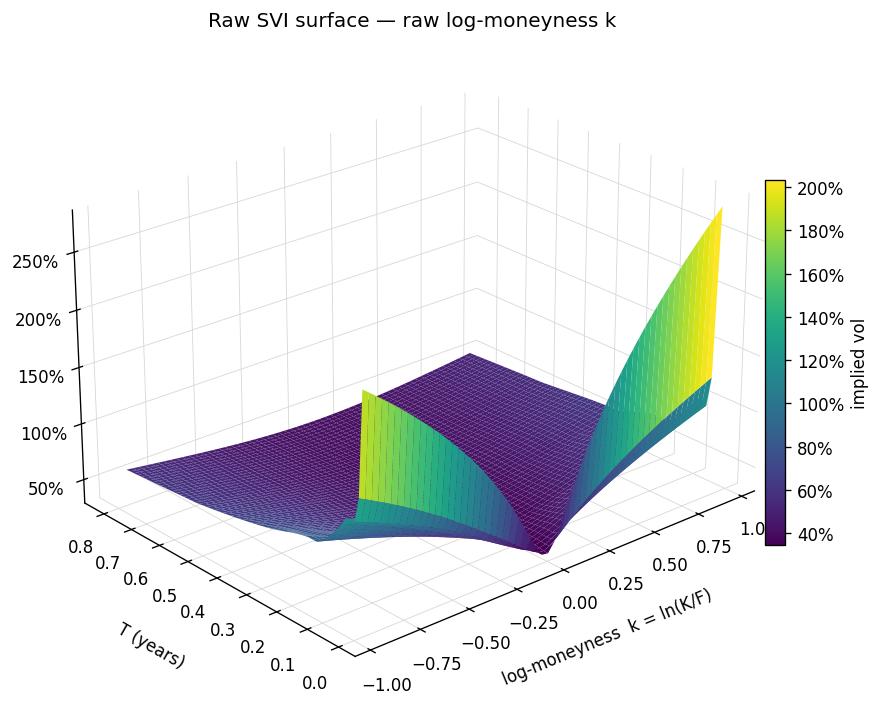

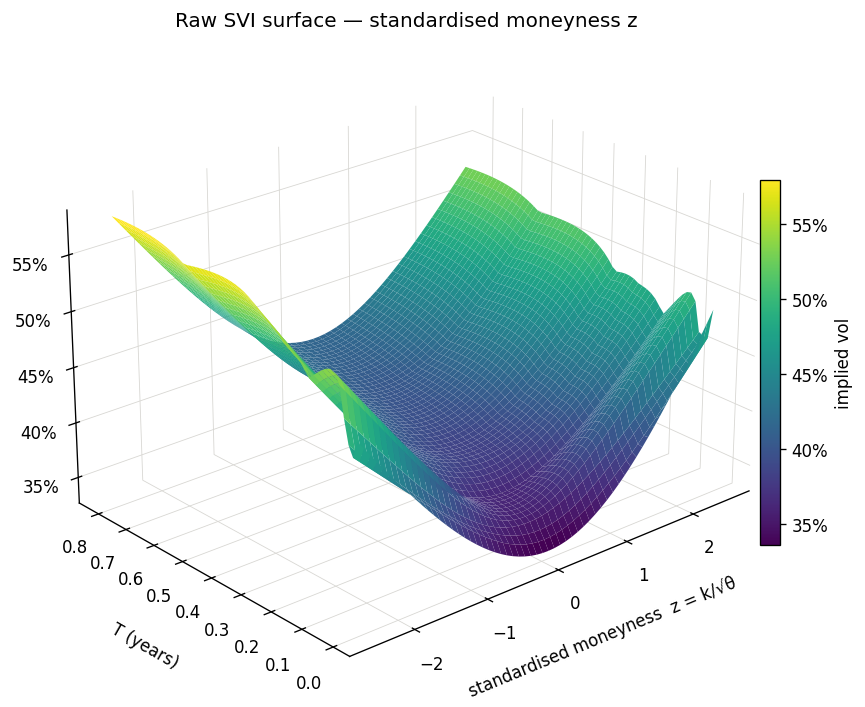

In [16]:

display(ge.plot_vol_surface(surf, x_axis='k', n_k=60, n_t=60, backend='matplotlib',
                            title='Raw SVI surface — raw log-moneyness k'))
display(ge.plot_vol_surface(surf, x_axis='z', n_k=60, n_t=60, backend='matplotlib',
                            title='Raw SVI surface — standardised moneyness z'))

### Interpolation modes and interior-region arbitrage (`interp_method`, `check_interior_arbitrage`)

`run_pipeline` above already builds `surf` with the defaults `interp_method="price_space"`
and `check_interior=True`, so `surf` already carries everything below. This section makes
the reasoning behind those defaults concrete.

`VolSurface.implied_vol` interpolates between two fitted knots two different ways:
- `"linear_variance"` blends total variance linearly in `T` at matched log-moneyness `k`.
  Simple, but Gatheral-Jacquier don't prove this is arbitrage-free between knots — and in
  general it isn't.
- `"price_space"` (the default) instead blends *undiscounted option prices* — Lemma 5.1:
  convert each knot's total variance to a normalized Black-Scholes price
  (`black_scholes_undiscounted_call`), blend with weight
  `alpha_T = (sqrt(theta_hi) - sqrt(theta_T)) / (sqrt(theta_hi) - sqrt(theta_lo))`, then
  invert the blended price back to a total variance via `brentq`. This interpolation
  scheme *is* proven arbitrage-free.

`check_interior_arbitrage` (wired into `fit_surface` via `check_interior=True`) is the
empirical safety net on top: it samples several maturities strictly between each pair of
knots and checks `g(k) >= 0` plus calendar-monotonicity there too. It's a real gate for
`"linear_variance"` (which has no proof); for `"price_space"` it's expected to always pass
by construction, so mostly a regression check.

Below: two knots that are each individually arbitrage-free (`check_butterfly` passes) and
jointly calendar-consistent (`check_calendar` passes at the knots) — yet interpolating
between them `"linear_variance"`-style produces a real violation strictly inside the gap,
while `"price_space"` interpolation, from the *exact same two knots*, does not.

both knots individually clean (check_butterfly) and jointly calendar-consistent (check_calendar)

linear_variance: check_interior_arbitrage caught a violation ->
  interior calendar arbitrage (numerical, interp_method='linear_variance'): interpolated total variance at T=0.2500 exceeds the T=1.0000 knot at k=0.4000

price_space:  check_interior_arbitrage -> True


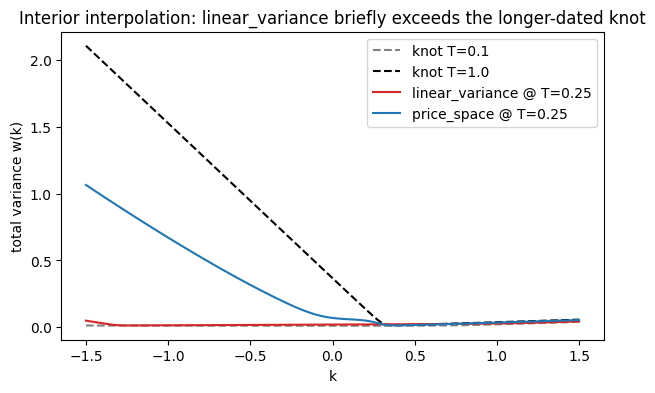


max(w_linear - w_hi_curve) = 6.0309e-03  (>0: calendar arbitrage -- variance would have to *drop* going from T_demo to T_hi)
max(w_price  - w_hi_curve) = -2.2906e-03  (price_space stays under the T_hi knot everywhere, as Lemma 5.1 guarantees)


In [17]:
from svi import SVIParams

# two knots, found via constrained global optimization: each individually
# clean and jointly calendar-consistent at the knots themselves.
T_lo, T_hi = 0.1, 1.0
F_lo, F_hi = 100.0, 14.321666131771952
p_lo = SVIParams(a=0.01, b=0.02, rho=0.9372200048289984, m=0.7263258516341791, sigma=0.2099731688362058)
p_hi = SVIParams(a=0.01, b=0.6, rho=-0.9341407150603276, m=0.3073088379262502, sigma=0.03)

assert arb.check_butterfly(p_lo) is True
assert arb.check_butterfly(p_hi) is True
assert arb.check_calendar([(T_lo, p_lo), (T_hi, p_hi)]) is True
print('both knots individually clean (check_butterfly) and jointly calendar-consistent (check_calendar)')

linear_surf = surface.VolSurface([T_lo, T_hi], [F_lo, F_hi], [p_lo, p_hi], interp_method='linear_variance')
price_surf = surface.VolSurface([T_lo, T_hi], [F_lo, F_hi], [p_lo, p_hi], interp_method='price_space')

try:
    surface.check_interior_arbitrage(linear_surf, n_points=5)
    print('\nlinear_variance: check_interior_arbitrage did not raise -- unexpected')
except arb.ArbitrageError as e:
    print('\nlinear_variance: check_interior_arbitrage caught a violation ->')
    print(' ', e)

print('\nprice_space:  check_interior_arbitrage ->', surface.check_interior_arbitrage(price_surf, n_points=5))

# Visualize directly: at an interior maturity, the interpolated total
# variance should sit strictly between the two knots' own curves. Plot it
# against the T_hi knot -- linear_variance pokes *above* it, which would
# mean a variance swap between T_demo and T_hi prices negative.
T_demo = 0.25
frac = (T_demo - T_lo) / (T_hi - T_lo)
F_demo = np.exp(np.log(F_lo) + (np.log(F_hi) - np.log(F_lo)) * frac)
K_demo = F_demo * np.exp(arb.DEFAULT_K_GRID)

w_lo_curve = p_lo.total_variance(arb.DEFAULT_K_GRID)
w_hi_curve = p_hi.total_variance(arb.DEFAULT_K_GRID)
w_linear = linear_surf.implied_vol(K_demo, T_demo) ** 2 * T_demo
w_price = price_surf.implied_vol(K_demo, T_demo) ** 2 * T_demo

plt.figure(figsize=(7, 4))
plt.plot(arb.DEFAULT_K_GRID, w_lo_curve, '--', color='gray', label=f'knot T={T_lo}')
plt.plot(arb.DEFAULT_K_GRID, w_hi_curve, '--', color='black', label=f'knot T={T_hi}')
plt.plot(arb.DEFAULT_K_GRID, w_linear, color='C3', label=f'linear_variance @ T={T_demo}')
plt.plot(arb.DEFAULT_K_GRID, w_price, color='C0', label=f'price_space @ T={T_demo}')
plt.xlabel('k'); plt.ylabel('total variance w(k)')
plt.title('Interior interpolation: linear_variance briefly exceeds the longer-dated knot')
plt.legend()
plt.show()

print(f'\nmax(w_linear - w_hi_curve) = {(w_linear - w_hi_curve).max():.4e}  '
      '(>0: calendar arbitrage -- variance would have to *drop* going from T_demo to T_hi)')
print(f'max(w_price  - w_hi_curve) = {(w_price - w_hi_curve).max():.4e}  '
      '(price_space stays under the T_hi knot everywhere, as Lemma 5.1 guarantees)')

### 4.2 SSVI surface fitting (`fit_ssvi_surface`) — a surface-wide guarantee (Corollary 4.1)

`fit_surface` + `check_interior_arbitrage` above gives per-knot arbitrage-freeness plus a
finite-grid empirical check between knots — good, but not a proof, and only as fine as the
sampled grid. `fit_ssvi_surface` takes a different approach: instead of independent
per-expiry raw-SVI fits stitched together after the fact, it fits the single
shared-`rho`, shared-shape-function SSVI parameterization (`ssvi.py`, Definition 4.1) to
the *whole* chain at once, then calls `ssvi.check_ssvi_no_static_arbitrage` (Theorem 4.1's
calendar condition + Theorem 4.2's butterfly condition, together giving Corollary 4.1).
When that passes, the surface is arbitrage-free **everywhere** — every `(K, T)`, not just
the fitted knots or a probe grid.

Internally: it pre-fits an independent raw-SVI slice per expiry purely to read off each
knot's ATM total variance `theta_t` and ATM skew, then fits `(rho, phi)` by least squares
against the closed-form SSVI skew `theta_t * rho * phi(theta_t)`. The returned
`SSVIVolSurface` exposes the same `implied_vol(K, T)` interface as `VolSurface` and drops
straight into `plot_surface_3d`.

In [18]:
ssvi_surf = None
for min_pts in (surface.MIN_POINTS_PER_SLICE, 10, 20, 30):
    try:
        ssvi_surf = surface.fit_ssvi_surface(chain, min_points=min_pts)
        print(f'fit_ssvi_surface passed check_ssvi_no_static_arbitrage with min_points={min_pts}')
        break
    except arb.ArbitrageError as e:
        print(f'min_points={min_pts}: rejected ->')
        print(' ', e)

print('\n', ssvi_surf.ssvi_params)
print('theta_t (ATM total variance at each knot):', ssvi_surf.theta_values)
print(f"knots: T in [{ssvi_surf.maturities[0]:.4f}, {ssvi_surf.maturities[-1]:.4f}]")

fit_ssvi_surface passed check_ssvi_no_static_arbitrage with min_points=5

 SSVIParams(rho=-0.07385777325376304, phi=<function phi_power_law.<locals>.phi at 0x7168a3c41260>)
theta_t (ATM total variance at each knot): [0.000111 0.000367 0.00073  0.00111  0.002966 0.005628 0.008373 0.021127
 0.034727 0.046765 0.091738 0.140945]
knots: T in [0.0011, 0.8120]


T=0.0011: min g(k) = 0.2557
T=0.1749: min g(k) = 0.3078
T=0.3488: min g(k) = 0.3331
T=0.5226: min g(k) = 0.3528
T=0.6965: min g(k) = 0.3701
T=0.8703: min g(k) = 0.3958
T=1.0442: min g(k) = 0.4377
T=1.2180: min g(k) = 0.4745

worst g(k) across all off-knot probes: 0.2557 -> arbitrage-free


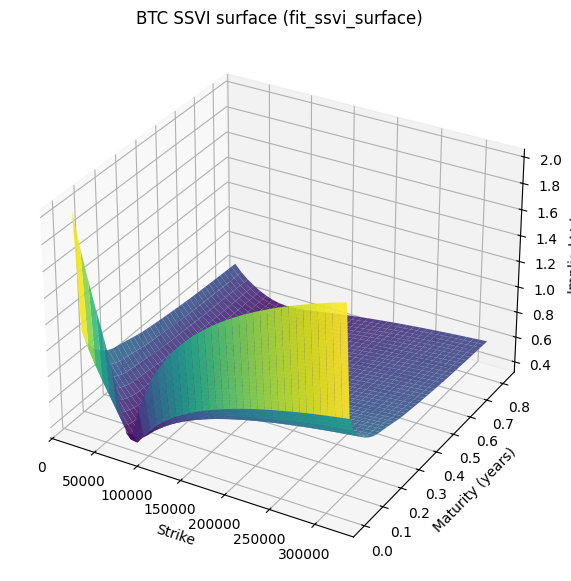

In [19]:
# Spot-check g(k) at several *off-knot* maturities (including beyond the
# last fitted expiry) via the same finite-difference formula
# check_interior_arbitrage uses. Corollary 4.1 says this should never find
# a butterfly violation anywhere -- not just at the knots fit_ssvi_surface
# saw -- unlike fit_surface, where that's only a probabilistic/grid-limited
# empirical check.
off_knot_Ts = np.linspace(ssvi_surf.maturities[0], ssvi_surf.maturities[-1] * 1.5, 8)
h = 1e-4
worst_g = np.inf
for T_probe in off_knot_Ts:
    F_probe = np.interp(T_probe, ssvi_surf.maturities, ssvi_surf.forwards)

    def w_at(k_shift, F_probe=F_probe, T_probe=T_probe):
        K = F_probe * np.exp(arb.DEFAULT_K_GRID + k_shift)
        return ssvi_surf.implied_vol(K, T_probe) ** 2 * T_probe

    w, w_p, w_m = w_at(0.0), w_at(h), w_at(-h)
    dw = (w_p - w_m) / (2 * h)
    d2w = (w_p - 2 * w + w_m) / h ** 2
    g = (1 - arb.DEFAULT_K_GRID * dw / (2 * w)) ** 2 - (dw ** 2 / 4) * (1 / w + 0.25) + d2w / 2
    worst_g = min(worst_g, g.min())
    print(f'T={T_probe:.4f}: min g(k) = {g.min():.4f}')

print(f'\nworst g(k) across all off-knot probes: {worst_g:.4f} -> '
      f'{"arbitrage-free" if worst_g > -1e-6 else "VIOLATION"}')
assert worst_g > -1e-6

fig, ax = surface.plot_surface_3d(ssvi_surf)
ax.set_title(f'{CURRENCY} SSVI surface (fit_ssvi_surface)')
plt.show()

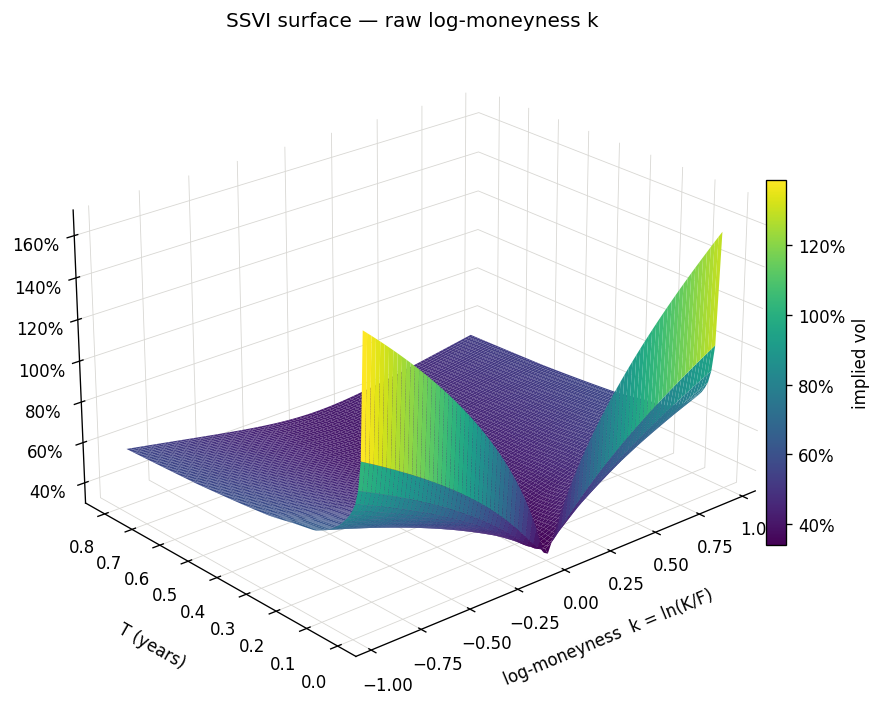

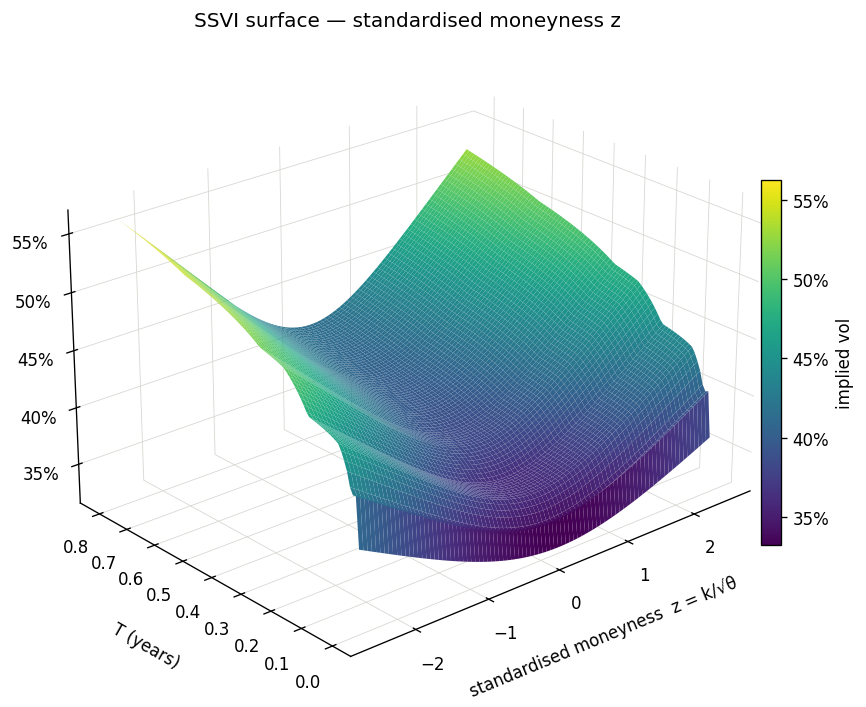

In [20]:
# Same camera, same colormap as the raw-SVI surface above and the eSSVI surface
# below -- the three are directly comparable.
# Two separate figures: raw log-moneyness k, then standardised moneyness
# z = k/sqrt(theta(T)). Both come from the same `plot_vol_surface`, so they share
# one camera and one colormap with every other surface in this project.
display(ge.plot_vol_surface(ssvi_surf, x_axis='k', n_k=90, n_t=90, backend='matplotlib',
                            title='SSVI surface — raw log-moneyness k'))
display(ge.plot_vol_surface(ssvi_surf, x_axis='z', n_k=90, n_t=90, backend='matplotlib',
                            title='SSVI surface — standardised moneyness z'))

## Step 7 — Global eSSVI (`global_essvi.py`) — a guarantee that needs no check

The third row of the table at the top of Step 6, and the last rung of its ladder: `fit_surface`
gives a per-knot guarantee plus a finite-grid empirical check between knots;
`fit_ssvi_surface` gives a surface-wide one but spends a single `rho` on every maturity to
get it.

`global_essvi.calibrate` is the next rung, from Mingone,
*"No arbitrage global parametrization for the eSSVI volatility surface"*
(arXiv:2204.00312). eSSVI writes each slice as

```
w(k,T) = ½[ θ + ρψk + √((ψk + θρ)² + θ²(1−ρ²)) ]     with ψ := θφ
```

and lets `rho` vary by maturity — the one thing SSVI gives up in exchange for its
guarantee.

The interesting part is *how* the guarantee is kept. Everything so far fits first and
validates afterwards, so there is always an admissible region the optimizer can leave.
Section 3 of the paper instead reparametrizes the admissible set itself as an open
hyperrectangle

```
rho_i ∈ ]−1,1[ ,  theta_1 ∈ ]0,∞[ ,  a_i ∈ ]0,∞[ ,  c_i ∈ ]0,1[
```

and gives an explicit map (`unbox`) from that box **onto** the surfaces satisfying the
no-arbitrage conditions. Proposition 3.1: every point of the box lands on an
arbitrage-free surface. So the calibration is an ordinary box-constrained least-squares
problem, there is no boundary to police, and `check_no_arbitrage` below is a test of the
*implementation* rather than a gate the result depends on.

In [21]:
# Same live chain as Steps 3/6, with one extra filter. `ge.filter_chain` keeps
# OTM only -- calls above the forward, puts below.
#

# This matters more than it looks. Deribit lists both a call and a put at every
# strike, so `chain` is roughly half in-the-money, and an ITM option is the wrong
# instrument to fit twice over: its price is almost all intrinsic, so its vega is
# negligible and inverting it for a vol is ill-conditioned (a live board carries
# deep ITM puts struck at 5x the forward whose quoted mid implies ~220% vol), and
# in a price-space objective those same quotes are worth multiples of an ATM
# option and dominate the sum of squares. By put-call parity the OTM twin carries
# the same information and is the liquid instrument at every strike.
otm = ge.filter_chain(chain)
print(f'{len(chain)} quotes -> {len(otm)} after OTM + expiry filtering '
      f'({otm["T"].nunique()} expiries)')

essvi_result = ge.calibrate(**ge.chain_to_calibration_inputs(otm))
essvi_surf = essvi_result.surface
print(essvi_result)
print(f'converged: {essvi_result.success} -- {essvi_result.opt_result.message}')

pd.DataFrame({
    'T': essvi_surf.maturities,
    'forward': essvi_surf.forwards,
    'theta': [s.theta for s in essvi_surf.slices],
    'rho': [s.rho for s in essvi_surf.slices],
    'psi': [s.psi for s in essvi_surf.slices],
    'ATM vol': [essvi_surf.implied_vol(F, T)
                for F, T in zip(essvi_surf.forwards, essvi_surf.maturities)],
}).round(5)

752 quotes -> 301 after OTM + expiry filtering (11 expiries)
CalibrationResult(success=True, n_quotes=301, weighted_rmse=27.2748, GlobalESSVISurface(N=11, T=[0.0038, 0.0066, 0.0093, 0.0257, 0.0449, 0.0641, 0.16, 0.2367, 0.3134, 0.5627, 0.812]))
converged: True -- `ftol` termination condition is satisfied.


,T,forward,theta,rho,psi,ATM vol
0,0.00381,77103.380,0.00042,-0.09881,0.01742,0.33298
1,0.00655,77113.980,0.00074,-0.04076,0.02451,0.33657
2,0.00929,77117.220,0.00112,-0.02243,0.02979,0.34751
3,0.02573,77167.280,0.00294,-0.05381,0.04541,0.33778
4,0.04491,77223.755,0.00565,-0.03891,0.06610,0.35484
5,0.06409,77269.120,0.00801,-0.03878,0.08336,0.35357
6,0.15998,77620.680,0.02113,-0.08133,0.12929,0.36344
7,0.23669,77931.460,0.03460,-0.08691,0.15003,0.38237
8,0.31340,78230.150,0.04733,-0.09645,0.17793,0.38862
9,0.56272,79117.990,0.09147,-0.08965,0.25268,0.40318


`theta` and `psi` come out strictly increasing and `rho` varies expiry to expiry. The
monotonicity is not a property of this chain — it is what `unbox` produces for *any* point
of the box, which is why the fit needs no arbitrage penalty term and no repair step.

In [22]:
# The Corollary 4.1 spot-check from Step 6, but run far wider: 300 maturities
# from well before the first expiry to well past the last, so the interpolation
# (Section 5.1) and BOTH extrapolation rules (5.2.1, 5.2.2) are exercised too.
# Butterfly is delegated to arbitrage.py's g(k), which knows nothing about eSSVI
# -- the point of routing through the raw-SVI map is that the checker stays
# independent of the code it is checking.
t_probe = np.geomspace(essvi_surf.maturities[0] * 0.2, essvi_surf.maturities[-1] * 3.0, 300)
ge.check_no_arbitrage(essvi_surf, t_grid=t_probe)
print(f'check_no_arbitrage passed over {len(t_probe)} maturities in '
      f'[{t_probe[0]:.4f}, {t_probe[-1]:.2f}]y')

worst_g = min(arb.g_function(arb.DEFAULT_K_GRID,
                             ge.essvi_slice_to_raw_svi(essvi_surf.slice_at(t))).min()
              for t in t_probe)
print(f'worst min g(k) anywhere on that range: {worst_g:.4f}  (> 0 => no butterfly arbitrage)')

check_no_arbitrage passed over 300 maturities in [0.0008, 2.44]y
worst min g(k) anywhere on that range: 0.2566  (> 0 => no butterfly arbitrage)


Compare that with Step 6: `fit_surface`'s interior check samples a handful of maturities
between adjacent knots and can only report what it happened to sample, while here the
result is guaranteed before the check runs. The check is regression protection for
`unbox`, not evidence about this particular surface.

How it compares against the other two fits is a question in its own right — parameter
count, fit quality, and how each behaves when the quotes are noisy — and
`notebooks/essvi_benchmark.ipynb` is devoted to it: raw SVI, SSVI and Global eSSVI on one
chain, plus a stress test that refits all three on perturbed quotes and counts how often
each produces an arbitrageable surface.

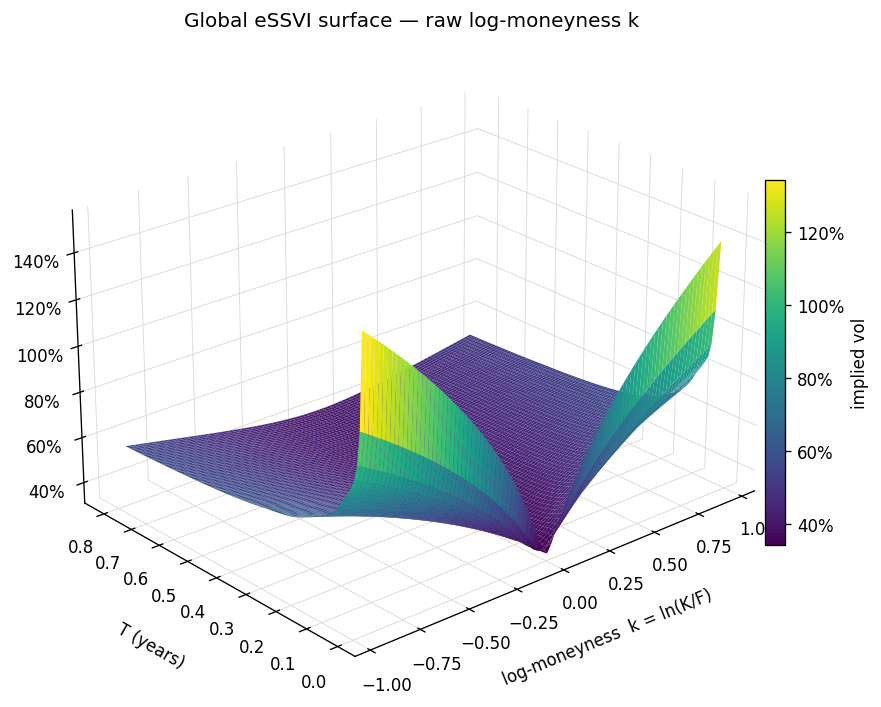

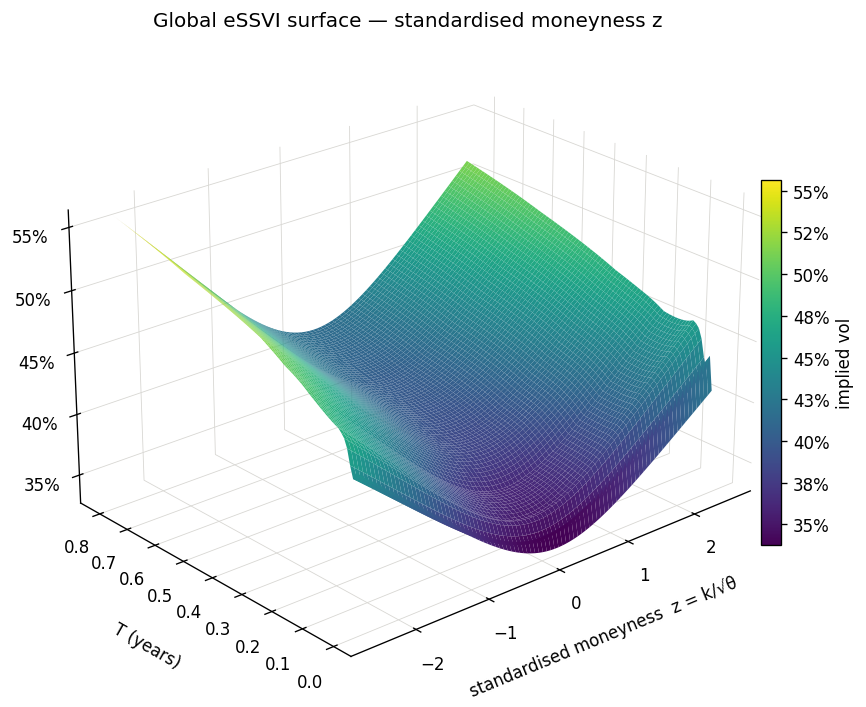

In [23]:
# panel's short-end spike is here than for raw SVI: eSSVI's wings are bounded by
# the butterfly conditions baked into the parametrization, so even well outside
# the quoted region it cannot run away the way an unconstrained SVI fit does.
# Two separate figures: raw log-moneyness k, then standardised moneyness
# z = k/sqrt(theta(T)). Both come from the same `plot_vol_surface`, so they share
# one camera and one colormap with every other surface in this project.
display(ge.plot_vol_surface(essvi_surf, x_axis='k', n_k=90, n_t=90, backend='matplotlib',
                            title='Global eSSVI surface — raw log-moneyness k'))
display(ge.plot_vol_surface(essvi_surf, x_axis='z', n_k=90, n_t=90, backend='matplotlib',
                            title='Global eSSVI surface — standardised moneyness z'))

## Pricing off the surface


In [24]:
def theoretical_price(surf, K, T, option_type):
    """Query the surface for implied vol at (K, T), then price off Step 1's bs.py."""
    F = np.interp(T, surf.maturities, surf.forwards)  # forward for an off-grid T
    iv_KT = surf.implied_vol(K, T)
    price = bs.price(F, K, T, 0.0, 0.0, iv_KT, option_type)
    return price, iv_KT, F

# price an on-grid ATM straddle at the nearest fitted expiry
K_atm = surf.forwards[0]
T0 = surf.maturities[0]
call_px, atm_iv, F0 = theoretical_price(surf, K_atm, T0, 'C')
put_px, _, _ = theoretical_price(surf, K_atm, T0, 'P')
print(f"T={T0:.4f}  F={F0:.2f}  ATM iv={atm_iv:.4f}")
print(f"ATM call = {call_px:.2f}   ATM put = {put_px:.2f}   straddle = {call_px + put_px:.2f}")

# a small option chain, off-grid strikes and an off-grid maturity, priced end to end
strikes_demo = surf.forwards[0] * np.array([0.85, 0.95, 1.0, 1.05, 1.15])
T_demo = 0.5 * (surf.maturities[0] + surf.maturities[1]) if len(surf.maturities) > 1 else surf.maturities[0]
otype_demo = np.where(strikes_demo >= surf.forwards[0], 'C', 'P')

rows = []
for K_i, otype_i in zip(strikes_demo, otype_demo):
    price_i, iv_i, F_i = theoretical_price(surf, K_i, T_demo, otype_i)
    rows.append({'strike': K_i, 'type': otype_i, 'T': T_demo, 'forward': F_i, 'iv': iv_i, 'theo price': price_i})

pd.DataFrame(rows)

T=0.0066  F=77114.12  ATM iv=0.3320
ATM call = 826.68   ATM put = 826.68   straddle = 1653.36


,strike,type,T,forward,iv,theo price
0,65547.002,P,0.007921,77115.67,0.780523,16.07858836882599
1,73258.414,P,0.007921,77115.67,0.424821,114.43077061225631
2,77114.120,C,0.007921,77115.67,0.341868,936.8132012722344
3,80969.826,C,0.007921,77115.67,0.410422,121.889508367095
4,88681.238,C,0.007921,77115.67,0.696908,21.529504279783737
